# Regresión lineal simple y múltiple con fútbol

Este notebook es una versión sencilla para estudiar para el examen.

Vamos a usar un ejemplo fácil:

> Queremos predecir cuántos goles mete un equipo en un partido.

Usaremos datos inventados pero realistas de partidos de fútbol.

Primero haremos:

1. **Regresión lineal simple**: predecir goles usando solo los tiros a puerta.
2. **Regresión lineal múltiple**: predecir goles usando varias variables:
   - tiros a puerta;
   - posesión;
   - corners;
   - ataques peligrosos.

La idea es entender el código, no complicarlo.

## 1. Importar librerías

Estas son las librerías básicas para hacer regresión lineal.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 2. Crear un dataset sencillo de fútbol

Cada fila representa un partido de un equipo.

Columnas:

- `equipo`: nombre del equipo.
- `tiros_a_puerta`: tiros que van entre los tres palos.
- `posesion`: porcentaje de posesión del balón.
- `corners`: saques de esquina.
- `ataques_peligrosos`: ataques con peligro.
- `goles`: goles marcados.

La variable que queremos predecir es:

```text
goles
```

In [2]:
datos = {
    "equipo": [
        "Real Madrid", "Barcelona", "Atletico", "Sevilla", "Betis",
        "Valencia", "Villarreal", "Real Sociedad", "Athletic", "Celta",
        "Getafe", "Osasuna", "Mallorca", "Girona", "Rayo",
        "Cadiz", "Alaves", "Granada", "Las Palmas", "Espanyol"
    ],
    "tiros_a_puerta": [9, 8, 6, 5, 5, 4, 6, 5, 4, 3, 2, 3, 2, 7, 4, 2, 3, 2, 4, 3],
    "posesion": [62, 65, 54, 52, 50, 48, 55, 57, 49, 45, 38, 43, 40, 59, 47, 36, 41, 39, 53, 44],
    "corners": [8, 7, 6, 5, 4, 5, 6, 5, 4, 3, 2, 3, 2, 7, 4, 2, 3, 2, 5, 3],
    "ataques_peligrosos": [75, 78, 65, 58, 55, 52, 61, 60, 50, 45, 35, 42, 38, 70, 48, 32, 40, 34, 54, 41],
    "goles": [4, 3, 2, 2, 1, 1, 2, 2, 1, 1, 0, 1, 0, 3, 1, 0, 1, 0, 2, 1]
}

df = pd.DataFrame(datos)

df

,equipo,tiros_a_puerta,posesion,corners,ataques_peligrosos,goles
0,Real Madrid,9,62,8,75,4
1,Barcelona,8,65,7,78,3
2,Atletico,6,54,6,65,2
3,Sevilla,5,52,5,58,2
4,Betis,5,50,4,55,1
5,Valencia,4,48,5,52,1
6,Villarreal,6,55,6,61,2
7,Real Sociedad,5,57,5,60,2
8,Athletic,4,49,4,50,1
9,Celta,3,45,3,45,1


## 3. Entender los datos

Antes de hacer el modelo miramos información básica.

In [3]:
print("Filas y columnas:", df.shape)

print("\nPrimeras filas:")
display(df.head())

print("\nEstadísticas básicas:")
display(df.describe())

Filas y columnas: (20, 6)

Primeras filas:


,equipo,tiros_a_puerta,posesion,corners,ataques_peligrosos,goles
0,Real Madrid,9,62,8,75,4
1,Barcelona,8,65,7,78,3
2,Atletico,6,54,6,65,2
3,Sevilla,5,52,5,58,2
4,Betis,5,50,4,55,1



Estadísticas básicas:


,tiros_a_puerta,posesion,corners,ataques_peligrosos,goles
count,20.000000,20.000000,20.000000,20.000000,20.000000
mean,4.350000,48.850000,4.300000,51.650000,1.400000
std,2.033276,8.247966,1.838191,13.635384,1.095445
min,2.000000,36.000000,2.000000,32.000000,0.000000
25%,3.000000,42.500000,3.000000,40.750000,1.000000
50%,4.000000,48.500000,4.000000,51.000000,1.000000
75%,5.250000,54.250000,5.250000,60.250000,2.000000
max,9.000000,65.000000,8.000000,78.000000,4.000000


# PARTE A — Regresión lineal simple

La regresión lineal simple usa **una sola variable** para predecir otra.

En este caso:

```text
X = tiros_a_puerta
y = goles
```

Es decir:

> Vamos a predecir los goles de un equipo usando solo sus tiros a puerta.

## 4. Elegir X e y

`X` son los datos que usamos para predecir.

`y` es lo que queremos predecir.

En regresión lineal simple, `X` tiene una sola columna.

In [4]:
X = df[["tiros_a_puerta"]]
y = df["goles"]

print("X:")
display(X.head())

print("y:")
display(y.head())

X:


,tiros_a_puerta
0,9
1,8
2,6
3,5
4,5


y:


0    4
1    3
2    2
3    2
4    1
Name: goles, dtype: int64

## 5. Dividir en entrenamiento y prueba

Dividimos los datos en dos partes:

- **Entrenamiento**: el modelo aprende.
- **Prueba/test**: comprobamos si el modelo predice bien.

Usamos el 80% para entrenar y el 20% para probar.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (16, 1)
Datos de prueba: (4, 1)


## 6. Crear y entrenar el modelo

Usamos `LinearRegression`.

Entrenar el modelo significa encontrar la recta que mejor relaciona:

```text
tiros_a_puerta → goles
```

In [ ]:
modelo_simple = LinearRegression() 
# LinearRegression es un modelo de regresión lineal que se utiliza para predecir una variable dependiente (en este caso, "goles") 
# a partir de una variable independiente (en este caso, "tiros_a_puerta"). 
# El modelo encuentra la mejor línea recta que se ajusta a los datos de entrenamiento, 
# minimizando la suma de los errores cuadrados entre las predicciones del modelo y los valores reales de la variable dependiente.

modelo_simple.fit(X_train, y_train)

print("Intercepto:", modelo_simple.intercept_)
print("Coeficiente:", modelo_simple.coef_[0])

Intercepto: -0.6850393700787405
Coeficiente: 0.4842519685039371


## 7. Fórmula del modelo simple

La fórmula de una regresión lineal simple es:

```text
goles = intercepto + coeficiente × tiros_a_puerta
```

Por ejemplo, si el coeficiente es positivo, significa que:

> Cuantos más tiros a puerta tenga un equipo, más goles se espera que marque.

In [7]:
print("Fórmula del modelo:")
print(f"goles = {modelo_simple.intercept_:.3f} + {modelo_simple.coef_[0]:.3f} × tiros_a_puerta")

Fórmula del modelo:
goles = -0.685 + 0.484 × tiros_a_puerta


## 8. Hacer predicciones

Ahora usamos el modelo para predecir los goles de los datos de prueba.

In [8]:
y_pred = modelo_simple.predict(X_test)

comparacion = pd.DataFrame({
    "tiros_a_puerta": X_test["tiros_a_puerta"].values,
    "goles_reales": y_test.values,
    "goles_predichos": y_pred
})

comparacion

,tiros_a_puerta,goles_reales,goles_predichos
0,9,4,3.673228
1,2,0,0.283465
2,2,0,0.283465
3,8,3,3.188976


## 9. Evaluar la regresión simple

Usamos estas métricas:

- `R2`: cuanto más cerca de 1, mejor.
- `MAE`: error medio absoluto. Cuanto más bajo, mejor.
- `RMSE`: error típico del modelo. Cuanto más bajo, mejor.

En este ejemplo, si el MAE es 0.5, significa que el modelo se equivoca de media en medio gol.

In [9]:
r2_simple = r2_score(y_test, y_pred)
mae_simple = mean_absolute_error(y_test, y_pred)
mse_simple = mean_squared_error(y_test, y_pred)
rmse_simple = np.sqrt(mse_simple)

print("MÉTRICAS DEL MODELO SIMPLE")
print("R2:", round(r2_simple, 3))
print("MAE:", round(mae_simple, 3))
print("MSE:", round(mse_simple, 3))
print("RMSE:", round(rmse_simple, 3))

MÉTRICAS DEL MODELO SIMPLE
R2: 0.976
MAE: 0.271
MSE: 0.076
RMSE: 0.275


## 10. Dibujar la regresión lineal simple

Como solo usamos una variable, podemos dibujar los puntos y la recta.

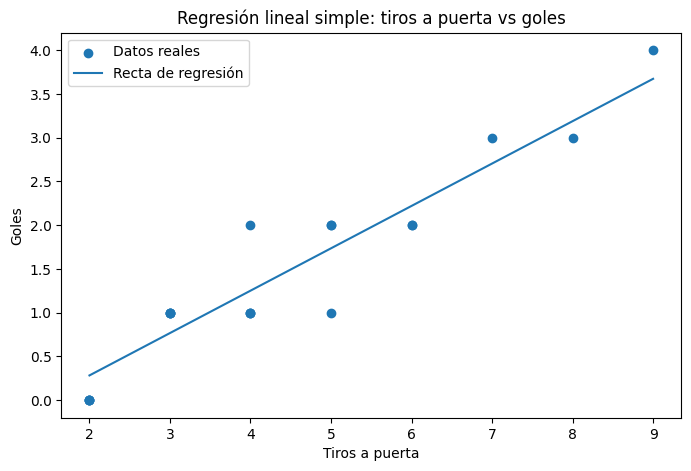

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y, label="Datos reales")

# Ordenamos los valores para que la línea salga bien dibujada
X_linea = pd.DataFrame({"tiros_a_puerta": sorted(df["tiros_a_puerta"])})
y_linea = modelo_simple.predict(X_linea)

plt.plot(X_linea, y_linea, label="Recta de regresión")

plt.xlabel("Tiros a puerta")
plt.ylabel("Goles")
plt.title("Regresión lineal simple: tiros a puerta vs goles")
plt.legend()
plt.show()

## 11. Predicción con un ejemplo nuevo

Supongamos que un equipo ha hecho 7 tiros a puerta.

Queremos predecir cuántos goles marcará.

In [11]:
nuevo_partido_simple = pd.DataFrame({
    "tiros_a_puerta": [7]
})

prediccion = modelo_simple.predict(nuevo_partido_simple)

print("Predicción de goles:", prediccion[0])
print("Predicción redondeada:", round(prediccion[0]))

Predicción de goles: 2.7047244094488194
Predicción redondeada: 3


### Explicación para examen de la regresión simple

Puedes copiar esto:

```text
En la regresión lineal simple he utilizado una sola variable predictora, tiros_a_puerta, para predecir la variable objetivo, goles.

Primero he separado X e y. X contiene los tiros a puerta e y contiene los goles.

Después he dividido los datos en entrenamiento y prueba usando train_test_split.

Luego he creado un modelo LinearRegression y lo he entrenado con fit.

Después he usado predict para obtener las predicciones sobre los datos de prueba.

Finalmente he evaluado el modelo con R2, MAE, MSE y RMSE.

Si el coeficiente es positivo, significa que al aumentar los tiros a puerta también aumenta la predicción de goles.
```

# PARTE B — Regresión lineal múltiple

La regresión lineal múltiple usa **varias variables** para predecir una variable objetivo.

Ahora queremos predecir los goles usando:

- tiros a puerta;
- posesión;
- corners;
- ataques peligrosos.

La variable objetivo sigue siendo:

```text
goles
```

## 12. Elegir X e y para regresión múltiple

Ahora `X` tiene varias columnas.

In [12]:
X_multi = df[["tiros_a_puerta", "posesion", "corners", "ataques_peligrosos"]]
y = df["goles"]

display(X_multi.head())
display(y.head())

,tiros_a_puerta,posesion,corners,ataques_peligrosos
0,9,62,8,75
1,8,65,7,78
2,6,54,6,65
3,5,52,5,58
4,5,50,4,55


0    4
1    3
2    2
3    2
4    1
Name: goles, dtype: int64

## 13. Dividir en entrenamiento y prueba

Igual que antes, pero ahora con varias variables.

In [13]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y,
    test_size=0.2,
    random_state=42
)

print("Datos de entrenamiento:", X_train_m.shape)
print("Datos de prueba:", X_test_m.shape)

Datos de entrenamiento: (16, 4)
Datos de prueba: (4, 4)


## 14. Crear y entrenar el modelo múltiple

Este modelo busca una fórmula como esta:

```text
goles = b0 + b1·tiros_a_puerta + b2·posesion + b3·corners + b4·ataques_peligrosos
```

In [14]:
modelo_multiple = LinearRegression()

modelo_multiple.fit(X_train_m, y_train_m)

print("Intercepto:", modelo_multiple.intercept_)

print("\nCoeficientes:")
for variable, coeficiente in zip(X_multi.columns, modelo_multiple.coef_):
    print(variable, ":", coeficiente)

Intercepto: -2.6479702160873826

Coeficientes:
tiros_a_puerta : 0.125991658624917
posesion : 0.09400754082583615
corners : 0.3279750193828637
ataques_peligrosos : -0.04886744035690576


## 15. Interpretar los coeficientes

Cada coeficiente indica la importancia de una variable dentro del modelo.

Por ejemplo:

- Si `tiros_a_puerta` tiene coeficiente positivo, más tiros suelen aumentar los goles.
- Si `corners` tiene coeficiente positivo, más corners pueden ayudar a marcar más.
- Si algún coeficiente sale negativo, significa que en este modelo esa variable reduce la predicción, aunque no siempre hay que interpretarlo literalmente.

En regresión múltiple hay que tener cuidado porque las variables pueden estar relacionadas entre sí.

In [15]:
coeficientes = pd.DataFrame({
    "variable": X_multi.columns,
    "coeficiente": modelo_multiple.coef_
})

coeficientes

,variable,coeficiente
0,tiros_a_puerta,0.125992
1,posesion,0.094008
2,corners,0.327975
3,ataques_peligrosos,-0.048867


## 16. Hacer predicciones con regresión múltiple

In [16]:
y_pred_m = modelo_multiple.predict(X_test_m)

comparacion_multiple = X_test_m.copy()
comparacion_multiple["goles_reales"] = y_test_m.values
comparacion_multiple["goles_predichos"] = y_pred_m

comparacion_multiple

,tiros_a_puerta,posesion,corners,ataques_peligrosos,goles_reales,goles_predichos
0,9,62,8,75,4,3.273164
17,2,39,2,34,0,0.264764
15,2,36,2,32,0,0.080477
1,8,65,7,78,3,2.954618


## 17. Evaluar la regresión múltiple

Calculamos las mismas métricas.

In [17]:
r2_multiple = r2_score(y_test_m, y_pred_m)
mae_multiple = mean_absolute_error(y_test_m, y_pred_m)
mse_multiple = mean_squared_error(y_test_m, y_pred_m)
rmse_multiple = np.sqrt(mse_multiple)

print("MÉTRICAS DEL MODELO MÚLTIPLE")
print("R2:", round(r2_multiple, 3))
print("MAE:", round(mae_multiple, 3))
print("MSE:", round(mse_multiple, 3))
print("RMSE:", round(rmse_multiple, 3))

MÉTRICAS DEL MODELO MÚLTIPLE
R2: 0.952
MAE: 0.279
MSE: 0.152
RMSE: 0.39


## 18. Comparar modelo simple y múltiple

Ahora comparamos:

- Modelo simple: usa solo tiros a puerta.
- Modelo múltiple: usa tiros, posesión, corners y ataques peligrosos.

El mejor modelo será el que tenga:

- mayor `R2`;
- menor `MAE`;
- menor `RMSE`.

In [18]:
resultados = pd.DataFrame({
    "modelo": ["Regresión simple", "Regresión múltiple"],
    "variables_usadas": [
        "tiros_a_puerta",
        "tiros_a_puerta, posesion, corners, ataques_peligrosos"
    ],
    "R2": [r2_simple, r2_multiple],
    "MAE": [mae_simple, mae_multiple],
    "RMSE": [rmse_simple, rmse_multiple]
})

resultados

,modelo,variables_usadas,R2,MAE,RMSE
0,Regresión simple,tiros_a_puerta,0.976220,0.270669,0.275316
1,Regresión múltiple,"tiros_a_puerta, posesion, corners, ataques_pel...",0.952398,0.279365,0.389527


## 19. Predicción con un partido nuevo

Supongamos que un equipo hace este partido:

- 8 tiros a puerta;
- 60% de posesión;
- 6 corners;
- 70 ataques peligrosos.

Vamos a predecir cuántos goles marcaría.

In [19]:
nuevo_partido_multiple = pd.DataFrame({
    "tiros_a_puerta": [8],
    "posesion": [60],
    "corners": [6],
    "ataques_peligrosos": [70]
})

prediccion_multiple = modelo_multiple.predict(nuevo_partido_multiple)

print("Predicción de goles:", prediccion_multiple[0])
print("Predicción redondeada:", round(prediccion_multiple[0]))

Predicción de goles: 2.5475447937759013
Predicción redondeada: 3


## 20. Gráfico de valores reales vs predichos

Este gráfico sirve para ver si el modelo predice bien.

Cuanto más cerca estén los puntos de la línea, mejor.

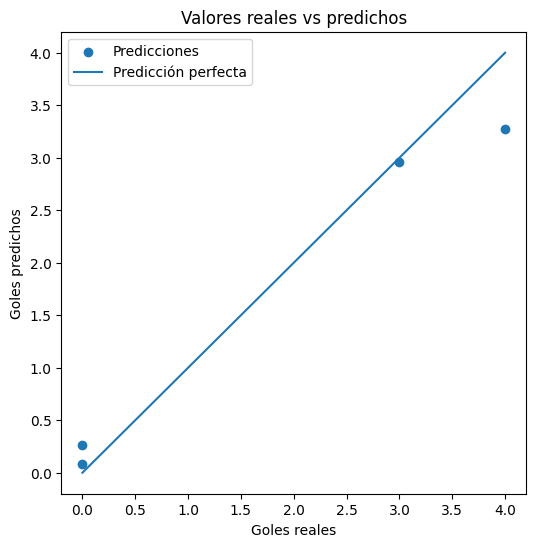

In [20]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test_m, y_pred_m, label="Predicciones")

minimo = min(y_test_m.min(), y_pred_m.min())
maximo = max(y_test_m.max(), y_pred_m.max())

plt.plot([minimo, maximo], [minimo, maximo], label="Predicción perfecta")

plt.xlabel("Goles reales")
plt.ylabel("Goles predichos")
plt.title("Valores reales vs predichos")
plt.legend()
plt.show()

### Explicación para examen de la regresión múltiple

Puedes copiar esto:

```text
En la regresión lineal múltiple he usado varias variables predictoras para predecir los goles.

Las variables predictoras han sido tiros_a_puerta, posesion, corners y ataques_peligrosos.

La variable objetivo ha sido goles.

Primero he separado X e y. En este caso X contiene varias columnas.

Después he dividido los datos en entrenamiento y prueba.

Luego he creado el modelo LinearRegression y lo he entrenado con fit.

Después he realizado predicciones con predict.

Finalmente he evaluado el modelo usando R2, MAE, MSE y RMSE.

La regresión múltiple puede ser mejor que la simple porque usa más información para hacer la predicción.
```

# PARTE C — Plantilla corta para examen

Esta es la plantilla básica que puedes adaptar.

In [21]:
# 1. Importar librerías
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 2. Crear o cargar datos
# df = pd.read_csv("archivo.csv")

# 3. Elegir variables

# Regresión simple:
# X = df[["una_variable"]]

# Regresión múltiple:
# X = df[["variable1", "variable2", "variable3"]]

# Variable objetivo:
# y = df["variable_objetivo"]

# 4. Dividir datos
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# 5. Crear modelo
# modelo = LinearRegression()

# 6. Entrenar modelo
# modelo.fit(X_train, y_train)

# 7. Predecir
# y_pred = modelo.predict(X_test)

# 8. Evaluar
# r2 = r2_score(y_test, y_pred)
# mae = mean_absolute_error(y_test, y_pred)
# mse = mean_squared_error(y_test, y_pred)
# rmse = np.sqrt(mse)

# print("R2:", r2)
# print("MAE:", mae)
# print("MSE:", mse)
# print("RMSE:", rmse)

# 9. Ver intercepto y coeficientes
# print("Intercepto:", modelo.intercept_)
# print("Coeficientes:", modelo.coef_)

# PARTE D — Chuleta rápida

```text
Regresión lineal simple:
Usa una sola variable para predecir otra.
Ejemplo: tiros_a_puerta → goles.

Regresión lineal múltiple:
Usa varias variables para predecir otra.
Ejemplo: tiros_a_puerta + posesion + corners + ataques_peligrosos → goles.

X:
Variables que uso para predecir.

y:
Variable que quiero predecir.

fit:
Entrena el modelo.

predict:
Hace predicciones.

R2:
Cuanto más cerca de 1, mejor.

MAE, MSE y RMSE:
Cuanto más bajos, mejor.

Intercepto:
Valor inicial del modelo.

Coeficientes:
Indican cuánto influye cada variable en la predicción.
```

# Conclusión final

```text
En este ejercicio se ha usado regresión lineal para predecir los goles de un equipo.

Primero se ha hecho una regresión simple usando solo los tiros a puerta.

Después se ha hecho una regresión múltiple usando tiros a puerta, posesión, corners y ataques peligrosos.

La regresión múltiple suele ser más completa porque tiene más información, pero la simple es más fácil de interpretar.
```